# ResNet-18 custom PTQ accuracy from 2 to 8 bits

This notebook evaluates one custom PTQ function repeatedly with `num_bits` set to 2, 3, 4, 5, 6, 7, and 8. It uses the existing trained ResNet-18 CIFAR-10 checkpoint and compares every quantized reconstruction with the original FP32 model.

The experiment is weight-only: selected weights are quantized mathematically and reconstructed for Keras evaluation. Activations remain FP32, no fake-quantization operations are inserted, and no retraining is performed. Reported sub-byte storage is theoretical packed storage.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.quantization.custom_quantization import (
    custom_ptq_n_bits,
    dequantize_tensor,
)

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")


/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.20.0
Keras: 3.14.1


## 1. Configuration

`BIT_WIDTHS` is the only sweep variable. Every run uses identical weights, tensor selection, per-channel policy, preprocessing, and test images.


In [2]:
MODEL_PATH = (
    PROJECT_ROOT / "artifacts" / "resnet18_cifar10_training"
    / "resnet18_cifar10_fp32.keras"
)
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "resnet18_custom_ptq_bit_sweep"

BIT_WIDTHS = list(range(2, 9))
QUANTIZE_MIN_RANK = 2
PER_CHANNEL = True
NUM_EVALUATION_SAMPLES = None  # None evaluates all 10,000 test images.
BATCH_SIZE = 32

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing trained model: {MODEL_PATH}. Run notebook 06 first."
    )
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Bit widths: {BIT_WIDTHS}")
print(f"Model: {MODEL_PATH}")


Bit widths: [2, 3, 4, 5, 6, 7, 8]
Model: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_cifar10_training/resnet18_cifar10_fp32.keras


## 2. Load the trained ResNet-18 and CIFAR-10


In [3]:
model = keras.models.load_model(MODEL_PATH, compile=False)
(_, _), (test_images, test_labels) = keras.datasets.cifar10.load_data()
test_labels = test_labels.reshape(-1).astype(np.int32)
if NUM_EVALUATION_SAMPLES is not None:
    test_images = test_images[:NUM_EVALUATION_SAMPLES]
    test_labels = test_labels[:NUM_EVALUATION_SAMPLES]

image_converter = keras_hub.layers.ResNetImageConverter(
    image_size=(224, 224),
    scale=[0.017124753831663668, 0.01750700280112045, 0.017429193899782133],
    offset=[-2.1179039301310043, -2.0357142857142856, -1.8044444444444445],
    interpolation="bicubic",
    crop_to_aspect_ratio=True,
)

def preprocess_images(images):
    return image_converter(images)

print(f"Evaluation images: {len(test_images):,}")
print(f"Parameter tensors: {len(model.weights)}")
model.summary(expand_nested=True)


Evaluation images: 10,000
Parameter tensors: 102


Model: "resnet18_cifar10_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ images (InputLayer)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_pad (ZeroPadding2D)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_conv (Conv2D)        │ (None, None, None, 64) │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_bn                   │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_relu (Activation)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pad (ZeroPadding2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pool (MaxPooling2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_add (Add)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_out          │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,191,242 (42.69 MB)

 Trainable params: 11,181,642 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

## 3. Confirm tensor selection

The custom function quantizes floating tensors with rank 2 or higher. For this ResNet-18, these are convolution and dense weight tensors. Rank-1 biases and batch-normalization parameters stay in their original precision.


In [4]:
coverage_rows = []
for weight in model.weights:
    values = weight.numpy()
    selected = (
        np.issubdtype(values.dtype, np.floating)
        and values.ndim >= QUANTIZE_MIN_RANK
    )
    coverage_rows.append({
        "tensor": getattr(weight, "path", weight.name),
        "rank": values.ndim,
        "shape": tuple(values.shape),
        "values": values.size,
        "custom_ptq_selected": selected,
    })
coverage_details = pd.DataFrame(coverage_rows)
coverage_summary = coverage_details.groupby("rank", as_index=False).agg(
    total_tensors=("tensor", "count"),
    total_values=("values", "sum"),
    quantized_tensors=("custom_ptq_selected", "sum"),
)
print(f"Selected tensors: {int(coverage_details.custom_ptq_selected.sum())}")
coverage_summary


Selected tensors: 21


,rank,total_tensors,total_values,quantized_tensors
0,1,81,19210,0
1,2,1,5120,1
2,4,20,11166912,20


## 4. Prediction and reconstruction helpers

`reconstruct_model()` consumes quantized tensors in the same model-weight order used by `custom_ptq_n_bits()`. Selected weights are dequantized; skipped weights are copied exactly.


In [5]:
def predict_keras_labels(keras_model, raw_images, batch_size=BATCH_SIZE):
    predictions = []
    for start in range(0, len(raw_images), batch_size):
        batch = preprocess_images(raw_images[start:start + batch_size])
        logits = keras_model(batch, training=False).numpy()
        predictions.append(np.argmax(logits, axis=1))
    return np.concatenate(predictions)

def reconstruct_model(source_model, weight_result):
    quantized_tensor_iter = iter(weight_result.tensors)
    reconstructed_weights = []
    for weight in source_model.weights:
        values = weight.numpy()
        selected = (
            np.issubdtype(values.dtype, np.floating)
            and values.ndim >= QUANTIZE_MIN_RANK
        )
        if selected:
            reconstructed = dequantize_tensor(next(quantized_tensor_iter))
            reconstructed_weights.append(reconstructed.astype(values.dtype))
        else:
            reconstructed_weights.append(values)
    try:
        next(quantized_tensor_iter)
        raise RuntimeError("Not all custom PTQ tensors were consumed.")
    except StopIteration:
        pass

    reconstructed_model = keras.models.load_model(MODEL_PATH, compile=False)
    reconstructed_model.set_weights(reconstructed_weights)
    return reconstructed_model


## 5. Evaluate FP32 once


In [6]:
print("Evaluating FP32 baseline...")
start = time.perf_counter()
fp32_predictions = predict_keras_labels(model, test_images)
fp32_evaluation_seconds = time.perf_counter() - start
fp32_correct = int(np.sum(fp32_predictions == test_labels))
fp32_accuracy = float(np.mean(fp32_predictions == test_labels))
print(f"FP32 accuracy: {fp32_accuracy * 100:.2f}%")
print(f"FP32 evaluation: {fp32_evaluation_seconds:.2f} s")


Evaluating FP32 baseline...
FP32 accuracy: 90.47%
FP32 evaluation: 132.08 s


## 6. Call the same custom PTQ function for 2–8 bits

The loop below changes only `num_bits`. A fresh reconstructed model is evaluated and released after every bit width to keep memory use controlled.


In [7]:
sweep_rows = []
for num_bits in BIT_WIDTHS:
    print(f"\nQuantizing and evaluating {num_bits}-bit weights...")
    quantization_start = time.perf_counter()

    # This is the one PTQ function used for every bit width.
    ptq_results = custom_ptq_n_bits(
        model,
        num_bits=num_bits,
        representative_samples=None,
        quantize_min_rank=QUANTIZE_MIN_RANK,
        per_channel=PER_CHANNEL,
    )
    weight_result = ptq_results["weights"]
    quantization_seconds = time.perf_counter() - quantization_start

    quantized_model = reconstruct_model(model, weight_result)
    evaluation_start = time.perf_counter()
    predictions = predict_keras_labels(quantized_model, test_images)
    evaluation_seconds = time.perf_counter() - evaluation_start

    correct = int(np.sum(predictions == test_labels))
    accuracy = float(np.mean(predictions == test_labels))
    sweep_rows.append({
        "num_bits": num_bits,
        "quantized_tensors": len(weight_result.tensors),
        "correct_predictions": correct,
        "test_images": len(test_labels),
        "accuracy_percent": accuracy * 100,
        "drop_from_fp32_percentage_points": (fp32_accuracy - accuracy) * 100,
        "estimated_packed_parameter_bytes": weight_result.quantized_size_bytes,
        "estimated_packed_parameter_mib": weight_result.quantized_size_bytes / 1024**2,
        "compression_ratio_vs_fp32": weight_result.compression_ratio,
        "memory_reduction_percent": weight_result.memory_reduction_percent,
        "quantization_seconds": quantization_seconds,
        "evaluation_seconds": evaluation_seconds,
    })
    print(
        f"{num_bits}-bit accuracy: {accuracy * 100:.2f}% | "
        f"drop: {(fp32_accuracy - accuracy) * 100:.2f} pp | "
        f"compression: {weight_result.compression_ratio:.2f}x"
    )

    del predictions, quantized_model, ptq_results, weight_result
    gc.collect()

sweep_table = pd.DataFrame(sweep_rows)
sweep_table



Quantizing and evaluating 2-bit weights...
2-bit accuracy: 10.00% | drop: 80.47 pp | compression: 15.60x

Quantizing and evaluating 3-bit weights...
3-bit accuracy: 11.23% | drop: 79.24 pp | compression: 10.49x

Quantizing and evaluating 4-bit weights...
4-bit accuracy: 11.56% | drop: 78.91 pp | compression: 7.91x

Quantizing and evaluating 5-bit weights...
5-bit accuracy: 49.39% | drop: 41.08 pp | compression: 6.34x

Quantizing and evaluating 6-bit weights...
6-bit accuracy: 71.87% | drop: 18.60 pp | compression: 5.29x

Quantizing and evaluating 7-bit weights...
7-bit accuracy: 88.05% | drop: 2.42 pp | compression: 4.54x

Quantizing and evaluating 8-bit weights...
8-bit accuracy: 89.88% | drop: 0.59 pp | compression: 3.98x


,num_bits,quantized_tensors,correct_predictions,test_images,accuracy_percent,drop_from_fp32_percentage_points,estimated_packed_parameter_bytes,estimated_packed_parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,quantization_seconds,evaluation_seconds
0,2,21,1000,10000,10.00,80.47,2869848,2.73690,15.598376,93.589076,0.037850,168.264215
1,3,21,1123,10000,11.23,79.24,4266352,4.06871,10.492563,90.469440,0.041462,181.828190
2,4,21,1156,10000,11.56,78.91,5662856,5.40052,7.905016,87.349804,0.043359,186.667972
3,5,21,4939,10000,49.39,41.08,7059360,6.73233,6.341222,84.230169,0.041913,190.960060
4,6,21,7187,10000,71.87,18.60,8455864,8.06414,5.293956,81.110533,0.043680,210.825740
5,7,21,8805,10000,88.05,2.42,9852368,9.39595,4.543574,77.990897,0.043621,201.513041
6,8,21,8988,10000,89.88,0.59,11248872,10.72776,3.979507,74.871261,0.041466,200.146966


## 7. Accuracy versus weight bit-width


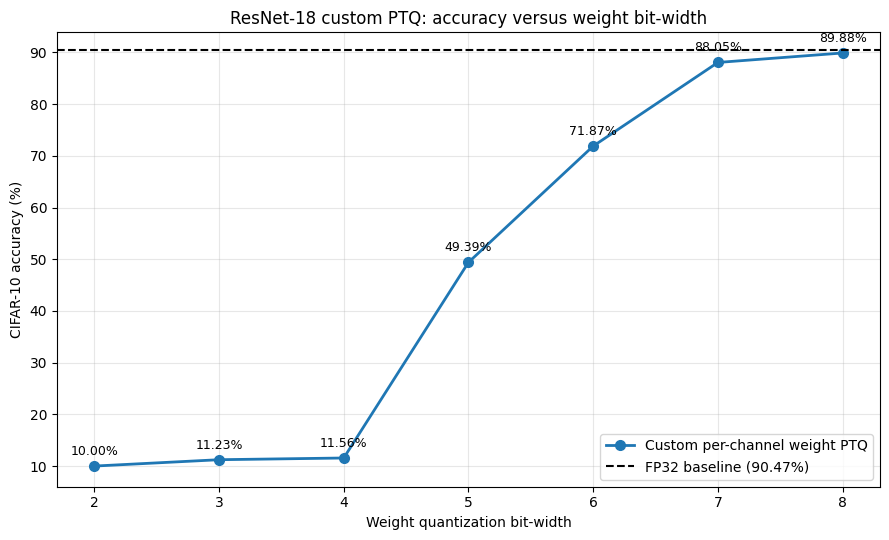

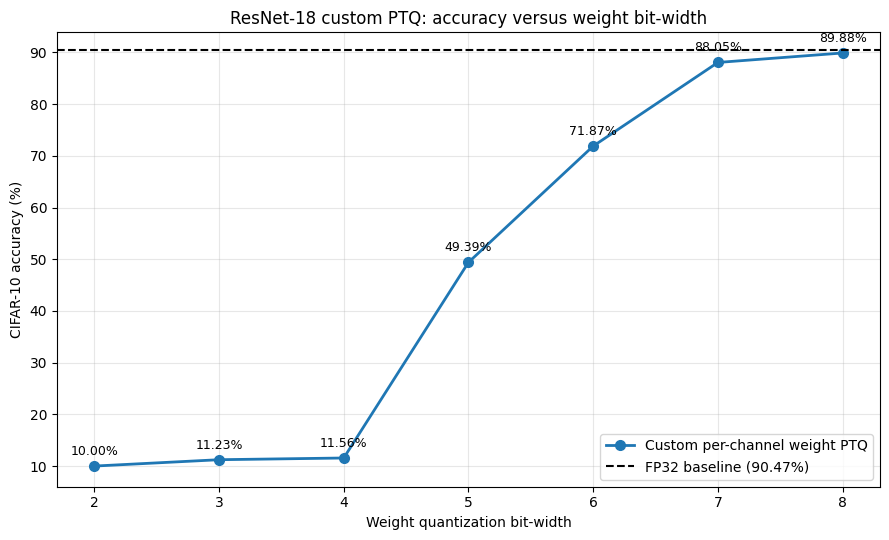

In [8]:
figure, axis = plt.subplots(figsize=(9, 5.5))
axis.plot(
    sweep_table["num_bits"],
    sweep_table["accuracy_percent"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="Custom per-channel weight PTQ",
)
axis.axhline(
    fp32_accuracy * 100,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"FP32 baseline ({fp32_accuracy * 100:.2f}%)",
)
for _, row in sweep_table.iterrows():
    axis.annotate(
        f"{row['accuracy_percent']:.2f}%",
        (row["num_bits"], row["accuracy_percent"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
    )
axis.set_xticks(BIT_WIDTHS)
axis.set_xlabel("Weight quantization bit-width")
axis.set_ylabel("CIFAR-10 accuracy (%)")
axis.set_title("ResNet-18 custom PTQ: accuracy versus weight bit-width")
axis.grid(True, alpha=0.3)
axis.legend()
figure.tight_layout()
figure


## 8. Accuracy and memory summary


In [9]:
fp32_row = pd.DataFrame([{
    "num_bits": "FP32",
    "quantized_tensors": 0,
    "correct_predictions": fp32_correct,
    "test_images": len(test_labels),
    "accuracy_percent": fp32_accuracy * 100,
    "drop_from_fp32_percentage_points": 0.0,
    "estimated_packed_parameter_mib": sum(
        weight.numpy().nbytes for weight in model.weights
    ) / 1024**2,
    "compression_ratio_vs_fp32": 1.0,
    "memory_reduction_percent": 0.0,
}])
final_table = pd.concat([fp32_row, sweep_table], ignore_index=True)
display_columns = [
    "num_bits", "quantized_tensors", "correct_predictions", "test_images",
    "accuracy_percent", "drop_from_fp32_percentage_points",
    "estimated_packed_parameter_mib", "compression_ratio_vs_fp32",
    "memory_reduction_percent",
]
final_table[display_columns]


,num_bits,quantized_tensors,correct_predictions,test_images,accuracy_percent,drop_from_fp32_percentage_points,estimated_packed_parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent
0,FP32,0,9047,10000,90.47,0.00,42.69120,1.000000,0.000000
1,2,21,1000,10000,10.00,80.47,2.73690,15.598376,93.589076
2,3,21,1123,10000,11.23,79.24,4.06871,10.492563,90.469440
3,4,21,1156,10000,11.56,78.91,5.40052,7.905016,87.349804
4,5,21,4939,10000,49.39,41.08,6.73233,6.341222,84.230169
5,6,21,7187,10000,71.87,18.60,8.06414,5.293956,81.110533
6,7,21,8805,10000,88.05,2.42,9.39595,4.543574,77.990897
7,8,21,8988,10000,89.88,0.59,10.72776,3.979507,74.871261


## 9. Save the experiment


In [10]:
accuracy_path = OUTPUT_DIR / "custom_ptq_2_to_8_bit_accuracy.csv"
coverage_path = OUTPUT_DIR / "custom_ptq_tensor_coverage.csv"
graph_path = OUTPUT_DIR / "custom_ptq_accuracy_vs_bits.png"
results_path = OUTPUT_DIR / "results.json"

sweep_table.to_csv(accuracy_path, index=False)
coverage_details.to_csv(coverage_path, index=False)
figure.savefig(graph_path, dpi=160, bbox_inches="tight")
results_path.write_text(json.dumps({
    "model": str(MODEL_PATH),
    "dataset": "CIFAR-10 test",
    "evaluation_images": int(len(test_labels)),
    "bit_widths": BIT_WIDTHS,
    "quantize_min_rank": QUANTIZE_MIN_RANK,
    "per_channel": PER_CHANNEL,
    "activations_quantized": False,
    "fp32_accuracy_percent": fp32_accuracy * 100,
    "accuracy_by_bits_percent": {
        str(int(row["num_bits"])): float(row["accuracy_percent"])
        for _, row in sweep_table.iterrows()
    },
    "reported_subbyte_storage_is_theoretical_packed_storage": True,
}, indent=2) + "\n", encoding="utf-8")
print(f"Saved table: {accuracy_path}")
print(f"Saved graph: {graph_path}")
print(f"Saved results: {results_path}")


Saved table: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_custom_ptq_bit_sweep/custom_ptq_2_to_8_bit_accuracy.csv
Saved graph: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_custom_ptq_bit_sweep/custom_ptq_accuracy_vs_bits.png
Saved results: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_custom_ptq_bit_sweep/results.json
